In [22]:
# Created a conda environment 
# conda install -c conda-forge swig box2d-py
# Python version 3.10.18

In [23]:
#! pip install "gymnasium[toy-text]
#! pip install pygame
#! pip install tqdm
#! pip install seaborn
#! pip install matplotlib
#! pip install numpy

In [24]:
import gymnasium as gym
import numpy as np
import random
from tqdm import trange
import matplotlib.pyplot as plt
import seaborn as sns
import torch


In [25]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
class BasicStrategyAgent:
    def select_action(self, obs):
        player_sum, dealer_card, usable_ace = obs

        # Always stick if 20 or 21
        if player_sum >= 20:
            return 0  # Stick
        # Stick on 17+ if no usable ace
        if player_sum >= 17 and not usable_ace:
            return 0
        # Stick on 18+ with usable ace
        if usable_ace and player_sum >= 18:
            return 0
        # Otherwise, hit
        return 1  # Hit

    def evaluate_agent(self, env, max_steps, n_eval_episodes, seed=None):
        rewards = []
        for ep in range(n_eval_episodes):
            obs, _ = env.reset(seed=seed + ep if seed is not None else None)
            total_reward = 0

            for _ in range(max_steps):
                action = self.select_action(obs)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                if terminated or truncated:
                    break

            rewards.append(total_reward)

        mean = np.mean(rewards)
        std = np.std(rewards)
        return mean, std, rewards

In [28]:
env = gym.make("Blackjack-v1", sab=True)  # Make sure `sab=True` for standard rules
max_steps = 100
n_eval_episodes = 10000
seed = 42

rule_agent = BasicStrategyAgent()
mean, std, _ = rule_agent.evaluate_agent(env, max_steps, n_eval_episodes, seed)
print(f"Rule-Based Agent: Mean_reward={mean:.2f} +/- {std:.2f}")


Rule-Based Agent: Mean_reward=-0.07 +/- 0.95


In [29]:
class Q_learningAgent:
    def __init__(self, env):
        self.env = env
        self.state_space = [space.n for space in env.observation_space.spaces]
        self.action_space = env.action_space.n
        self.Qtable1 = self.initialize_q_table(self.state_space, self.action_space)
        self.Qtable2 = self.initialize_q_table(self.state_space, self.action_space)
    
    def normalize(self, obs):
        return (obs[0], obs[1], int(obs[2]))

    def initialize_q_table(self, state_space, action_space):
        Qtable = np.zeros((*state_space, action_space), dtype=np.float32)
        return Qtable
    
    def epsilon_greedy_policy(self, state, epsilon):
        if random.uniform(0, 1) < epsilon:
            return self.env.action_space.sample()
        else:
            combined_Q = self.Qtable1[state] + self.Qtable2[state]
            return int(np.argmax(combined_Q))
    
    def greedy_policy(self, state):
        combined_Q = self.Qtable1[state] + self.Qtable2[state]
        return int(np.argmax(combined_Q))
    
    def train(self, n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, learning_rate, gamma):
        episode_rewards = []
        for episode in trange(n_training_episodes):
        
            epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
            obs, info = self.env.reset(seed=SEED)
            state = self.normalize(obs)
            total_rewards = 0

            for _ in range(max_steps):
                action = self.epsilon_greedy_policy(state, epsilon)
                next_state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                new_state = self.normalize(next_state)

                if random.random() < 0.5:
                    best_next_action = np.argmax(self.Qtable1[new_state])
                    td_target = reward + gamma * self.Qtable2[new_state][best_next_action]
                    self.Qtable1[state][action] += learning_rate * (td_target - self.Qtable1[state][action])
                else:
                    best_next_action = np.argmax(self.Qtable2[new_state])
                    td_target = reward + gamma * self.Qtable1[new_state][best_next_action]
                    self.Qtable2[state][action] += learning_rate * (td_target - self.Qtable2[state][action])
                
                total_rewards += reward
                # If done, finish the episode
                if done:
                    break
                state = new_state

            episode_rewards.append(total_rewards)

        return self.Qtable1 + self.Qtable2, episode_rewards
    
    def evaluate_agent(self, env, max_steps, n_eval_episodes, seed=None):

        episode_rewards = []
        
        for episode in range(n_eval_episodes):
            if seed:
                state, info = env.reset(seed=seed[episode])
            else:
                state, info = env.reset()
            state = self.normalize(state)

            total_rewards_ep = 0
        
            for _ in range(max_steps):
                # Take the action (index) that have the maximum reward
                Q_combined = self.Qtable1 + self.Qtable2
                action = np.argmax(Q_combined[state])
                next_state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                new_state = self.normalize(next_state)
                
                total_rewards_ep += reward
                if done:
                    break
                state = new_state

            episode_rewards.append(total_rewards_ep)

        mean_reward = np.mean(episode_rewards)
        std_reward = np.std(episode_rewards)

        return mean_reward, std_reward, episode_rewards


In [30]:
env = gym.make('Blackjack-v1', natural=False, sab=True, render_mode="rgb_array")

In [31]:
best_score = env.spec.reward_threshold
print(best_score)

None


In [32]:
ql_agent = Q_learningAgent(env=env)

In [33]:
state, info = ql_agent.env.reset()
state

(18, 10, 0)

In [34]:
print(ql_agent.env.observation_space)

print(ql_agent.env.action_space.n)

Tuple(Discrete(32), Discrete(11), Discrete(2))
2


Q-Table

In [35]:
Qtable_blackjack = ql_agent.initialize_q_table(ql_agent.state_space, ql_agent.action_space)
Qtable_blackjack

array([[[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        ...,

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]],


       [[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        ...,

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]],


       [[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        ...,

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]],


       ...,


       [[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

        ...,

        [[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]],

    

Training Parameters

In [38]:
# Training parameters
training_episodes = 1000000
learning_rate = 0.1

# Evaluation parameters
n_eval_episodes = 100000      

# Environment parameters
max_steps = 10
gamma = 1                    

# Exploration parameters
max_epsilon = 1.0           
min_epsilon = 0.05          
decay_rate = 0.0005

Training Function

In [39]:
ql_agent.Qtable, ql_rewards  = ql_agent.train(training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, learning_rate, gamma)

100%|██████████| 1000000/1000000 [02:07<00:00, 7870.93it/s]


In [40]:
eval_seed = [SEED + i for i in range(n_eval_episodes)]

In [41]:
# Evaluate our Agent
mean_reward, std_reward, episode_rewards = ql_agent.evaluate_agent(env, max_steps, n_eval_episodes, seed=eval_seed)
print(f"Mean_reward={mean_reward:.2f} +/- {std_reward:.2f}")

Mean_reward=-0.18 +/- 0.96


In [42]:
# === Evaluation Function ===
def evaluate(model, env_name="Blackjack-v1", episodes=3, seed=42):
    test_env = gym.make(env_name, sab=True, render_mode="human")
    
    for ep in range(episodes):
        obs, _ = test_env.reset(seed=seed + ep)
        state = model.normalize(obs)
        total_reward = 0

        for _ in range(100):
            # Greedy action from combined Q-table
            Q_combined = model.Qtable1 + model.Qtable2
            action = np.argmax(Q_combined[state])
            
            obs, reward, term, trunc, _ = test_env.step(action)
            total_reward += reward

            if term or trunc:
                break
            state = model.normalize(obs)

        print(f"Eval Episode {ep + 1}: Total Reward = {total_reward:.1f}")

    test_env.close()

In [43]:
evaluate(ql_agent)

Eval Episode 1: Total Reward = 1.0
Eval Episode 2: Total Reward = 0.0
Eval Episode 3: Total Reward = -1.0


Expected SARSA

In [44]:
class ExpectedSarsaAgent:

    def __init__(self, env):
        self.env = env
        self.state_space = [space.n for space in env.observation_space.spaces]
        self.action_space = env.action_space.n
        self.Qtable = self.initialize_q_table(self.state_space, self.action_space)

    def initialize_q_table(self, state_space, action_space):
        return np.zeros((*state_space, action_space), dtype=np.float32)

    def normalize(self, obs):
        """
        Normalize the observation to a tuple of (x, y, dealer_card).
        params:
            obs (tuple): The observation from the environment.
        """
        return (obs[0], obs[1], int(obs[2]))

    def get_Q_value(self, state, action):
        return self.Qtable[state][action]

    def act(self, state, epsilon=0.1):
        # Choose a random action
        if random.random() < epsilon:
            action = random.choice(self.actions)
        # Choose the greedy action
        else:
            action = self.greedy_action_selection(state)
        
        return action

    def learn(self, state, action, reward, next_state, epsilon):
        """
        Expected Sarsa update
        """

        next_state_probs = self.action_probs(next_state, epsilon) # Probability for taking each action in next state
        q_next_state = [self.get_Q_value(next_state, action) for action in self.actions] # Q-values for each action in next state
        next_state_expectation = sum([a*b for a, b in zip(next_state_probs, q_next_state)])

        self.Qtable[state][action] += learning_rate * (
            reward + gamma * next_state_expectation - self.Qtable[state][action]
        )

    def train(self, n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, learning_rate, gamma):
        episode_rewards = []

        for episode in trange(n_training_episodes):
            epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
            obs, _ = self.env.reset(seed=SEED)
            state = self.normalize(obs)
            total_rewards = 0

            for _ in range(max_steps):
                action_probs = np.ones(self.action_space) * (epsilon / self.action_space)
                best_action = np.argmax(self.Qtable[state])
                action_probs[best_action] += 1.0 - epsilon
                action = np.random.choice(np.arange(self.action_space), p=action_probs)

                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                next_state = self.normalize(next_obs)

                expected_q = np.dot(action_probs, self.Qtable[next_state])
                td_target = reward + gamma * expected_q
                self.Qtable[state][action] += learning_rate * (td_target - self.Qtable[state][action])

                total_rewards += reward
                if done:
                    break
                state = next_state

            episode_rewards.append(total_rewards)

        return self.Qtable, episode_rewards

    def greedy_action_selection(self, state):
        """
        Selects action with the highest Q-value for the given state.
        """
        # Get all the Q-values for all possible actions for the state
        q_values = [self.get_Q_value(state, action) for action in self.actions]
        maxQ = max(q_values)
        # There might be cases where there are multiple actions with the same high q_value. Choose randomly then
        count_maxQ = q_values.count(maxQ)
        if count_maxQ > 1:
            # Get all the actions with the maxQ
            best_action_indexes = [i for i in range(len(self.actions)) if q_values[i] == maxQ]
            action_index = random.choice(best_action_indexes)
        else:
            action_index = q_values.index(maxQ)
            
        return self.actions[action_index]

    def action_probs(self, state, epsilon):
        """
        Returns the probability of taking each action in the next state.
        """
        next_state_probs = [epsilon/len(self.actions)] * len(self.actions)
        best_action = self.greedy_action_selection(state)
        next_state_probs[best_action] += (1.0 - epsilon)

        return next_state_probs
    
    def evaluate_agent(self, env, max_steps, n_eval_episodes, Q, seed=None):

        episode_rewards = []
        
        for episode in range(n_eval_episodes):
            if seed:
                state, _ = env.reset(seed=seed[episode])
            else:
                state, info = env.reset()
            state = self.normalize(state)

            done = False
            total_rewards_ep = 0
        
            for _ in range(max_steps):
            # Take the action (index) that have the maximum reward
                action = np.argmax(Q[state])
                obs, reward, terminated, truncated, info = env.step(action)
                total_rewards_ep += reward
                new_state = self.normalize(obs)
                done = terminated or truncated
            
                if done:
                    break
                state = new_state

            episode_rewards.append(total_rewards_ep)
        mean_reward = np.mean(episode_rewards)
        std_reward = np.std(episode_rewards)

        return mean_reward, std_reward, episode_rewards

In [45]:
esarsa_agent = ExpectedSarsaAgent(env)

In [46]:
Qtable_blackjack1 = esarsa_agent.initialize_q_table(esarsa_agent.state_space, esarsa_agent.action_space)

In [47]:
def epsilon_schedule(ep):
    return max(0.01, 1.0 * np.exp(-0.001 * ep))

In [48]:
esarsa_Qtable, esarsa_rewards = esarsa_agent.train(
    training_episodes,
    min_epsilon=min_epsilon,
    max_epsilon=max_epsilon,
    decay_rate=decay_rate,
    env=env,
    max_steps=100,
    learning_rate=learning_rate,
    gamma=0.99
)

100%|██████████| 1000000/1000000 [05:31<00:00, 3012.96it/s]


In [49]:
# Evaluate our Agent
mean_reward_esarsa, std_reward_esarsa, episode_rewards_esarsa = esarsa_agent.evaluate_agent(env, max_steps, n_eval_episodes, Qtable_blackjack1, seed=eval_seed )
print(f"Mean_reward={mean_reward_esarsa:.2f} +/- {std_reward_esarsa:.2f}")

Mean_reward=-0.18 +/- 0.96


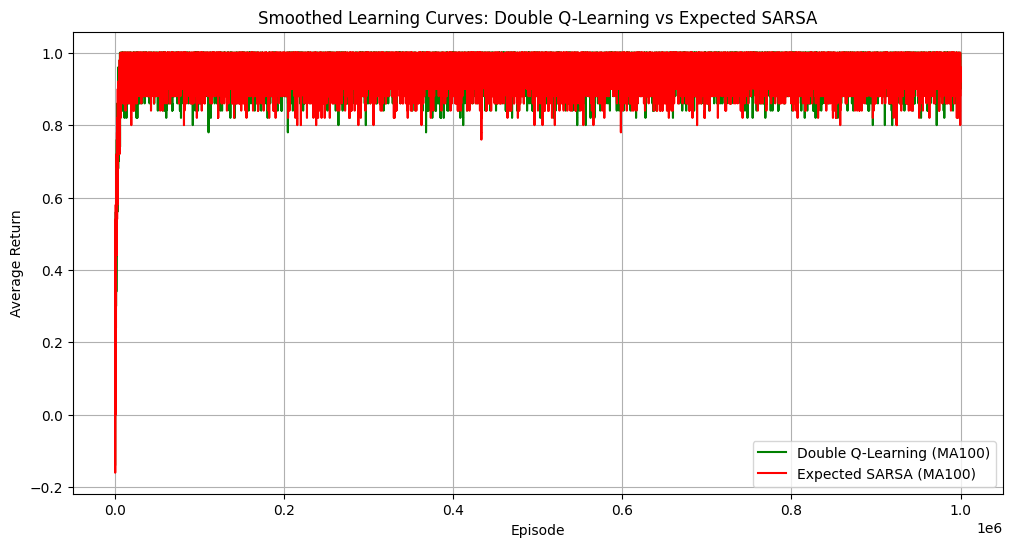

In [50]:
def moving_average(data, window_size=100):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(moving_average(ql_rewards), label='Double Q-Learning (MA100)', color='green')
plt.plot(moving_average(esarsa_rewards), label='Expected SARSA (MA100)', color='red')
plt.xlabel("Episode")
plt.ylabel("Average Return")
plt.title("Smoothed Learning Curves: Double Q-Learning vs Expected SARSA")
plt.legend()
plt.grid(True)
plt.show()


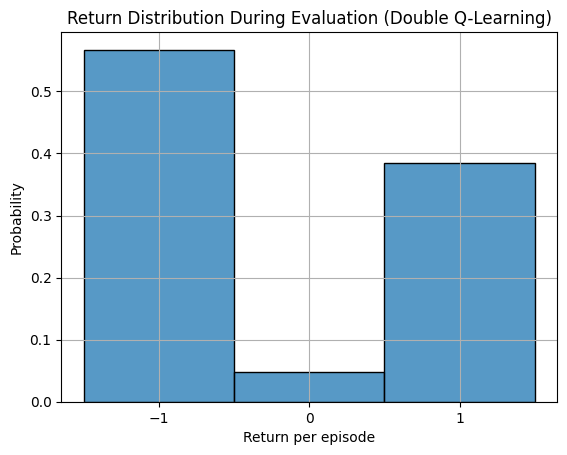

In [51]:
_, _, eval_returns_ql = ql_agent.evaluate_agent(env, max_steps=100, n_eval_episodes=10000, seed=None)

sns.histplot(eval_returns_ql, bins=[-1.5, -0.5, 0.5, 1.5], stat="probability", discrete=True)
plt.xticks([-1, 0, 1])
plt.xlabel("Return per episode")
plt.ylabel("Probability")
plt.title("Return Distribution During Evaluation (Double Q-Learning)")
plt.grid(True)
plt.show()

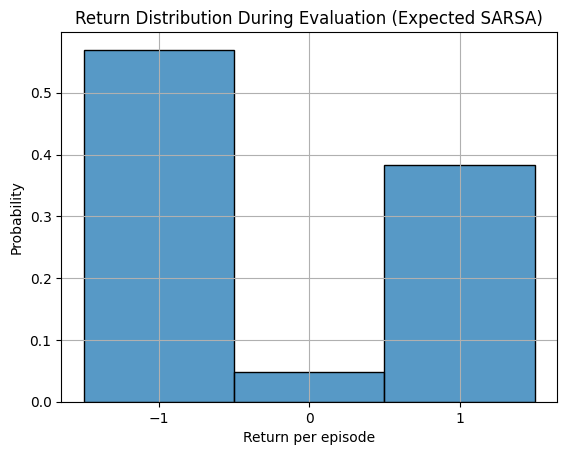

In [52]:
_, _, eval_returns_esarsa = esarsa_agent.evaluate_agent(env, max_steps=100, n_eval_episodes=10000, Q=Qtable_blackjack1, seed=None)

sns.histplot(eval_returns_esarsa, bins=[-1.5, -0.5, 0.5, 1.5], stat="probability", discrete=True)
plt.xticks([-1, 0, 1])
plt.xlabel("Return per episode")
plt.ylabel("Probability")
plt.title("Return Distribution During Evaluation (Expected SARSA)")
plt.grid(True)
plt.show()

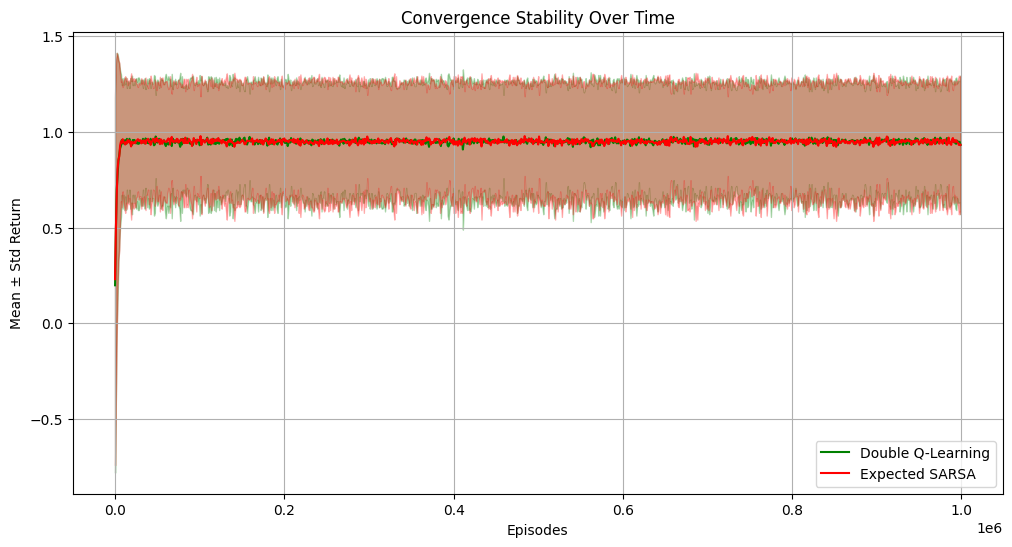

In [53]:
def chunked_statistics(rewards, chunk_size=1000):
    chunks = [rewards[i:i+chunk_size] for i in range(0, len(rewards), chunk_size)]
    means = [np.mean(chunk) for chunk in chunks]
    stds = [np.std(chunk) for chunk in chunks]
    return means, stds

means_q, stds_q = chunked_statistics(ql_rewards)
means_sarsa, stds_sarsa = chunked_statistics(esarsa_rewards)

episodes = np.arange(len(means_q)) * 1000

plt.figure(figsize=(12, 6))
plt.plot(episodes, means_q, label='Double Q-Learning', color='green')
plt.fill_between(episodes, np.array(means_q)-stds_q, np.array(means_q)+stds_q, alpha=0.3, color='green')

plt.plot(episodes, means_sarsa, label='Expected SARSA', color='red')
plt.fill_between(episodes, np.array(means_sarsa)-stds_sarsa, np.array(means_sarsa)+stds_sarsa, alpha=0.3, color='red')

plt.xlabel("Episodes")
plt.ylabel("Mean ± Std Return")
plt.title("Convergence Stability Over Time")
plt.legend()
plt.grid(True)
plt.show()


In [54]:
def plot_blackjack_q_heatmap(Qtable, usable_ace, title_prefix):

    # Filter for player sum 12–21, dealer 1–10
    state_values = np.max(Qtable[12:22, 1:11, int(usable_ace), :], axis=2)

    sns.heatmap(
        state_values.T,
        cmap="viridis",
        xticklabels=range(12, 22),
        yticklabels=range(1, 11),
        annot=True,
        fmt=".1f",
        annot_kws={'size': 8}
    )
    
    plt.suptitle(f"{title_prefix} Heatmaps (Usable Ace Comparison\nDarker = Worse, Brighter = Better")
    plt.xlabel("Player Sum")
    plt.ylabel("Dealer Showing")
    plt.tight_layout()
    plt.show()


In [55]:
def plot_learned_policy(Qtable, usable_ace=False, title_prefix = None):
    policy = np.argmax(Qtable[:, :, int(usable_ace), :], axis=-1)

    player_range = range(12, 22)
    dealer_range = range(1, 11)

    # Slice the relevant region (assumes indexing matches directly)
    policy_sub = policy[12:22, 0:10]

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(policy_sub.T, cmap="coolwarm", cbar=True, linewidths=0.5,
                xticklabels=player_range,
                yticklabels=dealer_range,
                annot=True, fmt="d", annot_kws={'size': 10})
    
    for text in ax.texts:
        val = int(text.get_text())
        text.set_text("Hit" if val == 1 else "Stick")
        text.set_color("white" if val == 1 else "black")
    plt.xlabel("Player Sum")
    plt.ylabel("Dealer Showing")
    plt.title(f"{title_prefix} Learned Policy (Usable Ace = {usable_ace})")
    plt.tight_layout()
    plt.show()

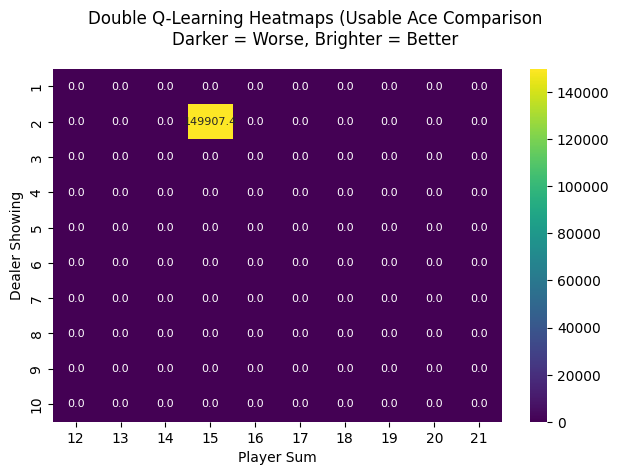

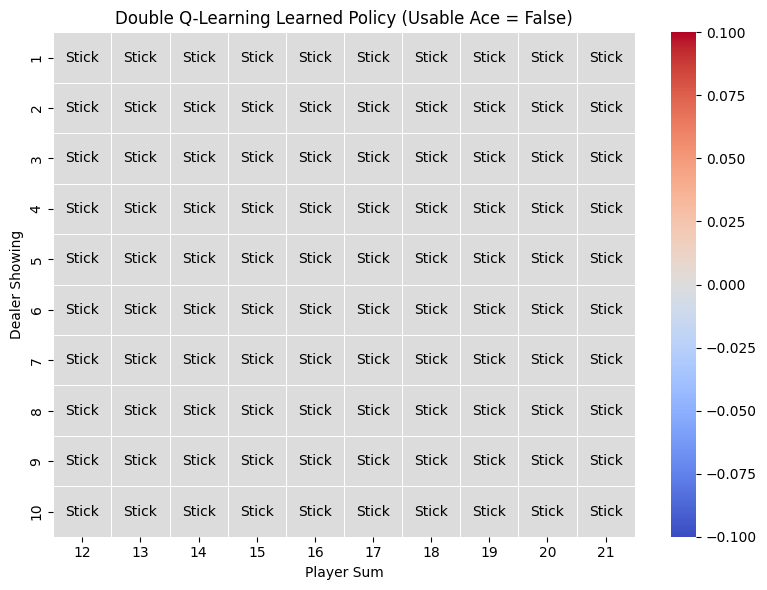

In [56]:
plot_blackjack_q_heatmap(ql_agent.Qtable, usable_ace=False, title_prefix="Double Q-Learning")
plot_learned_policy(ql_agent.Qtable, usable_ace=False, title_prefix="Double Q-Learning")

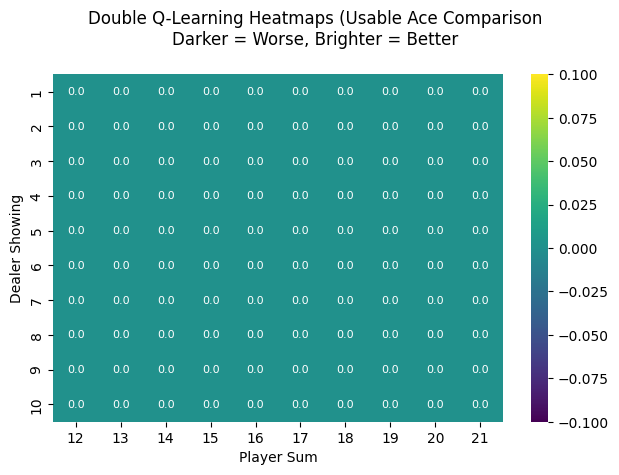

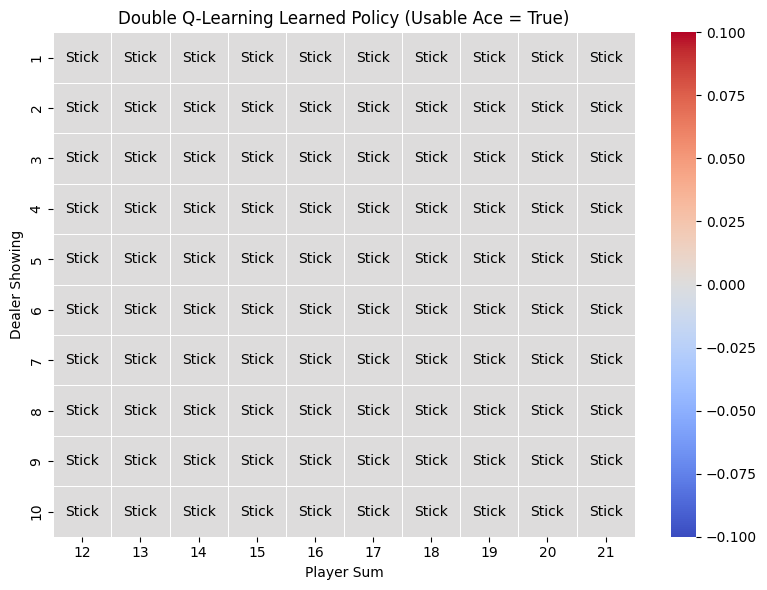

In [57]:
plot_blackjack_q_heatmap(ql_agent.Qtable, usable_ace=True, title_prefix="Double Q-Learning")
plot_learned_policy(ql_agent.Qtable, usable_ace=True, title_prefix="Double Q-Learning")

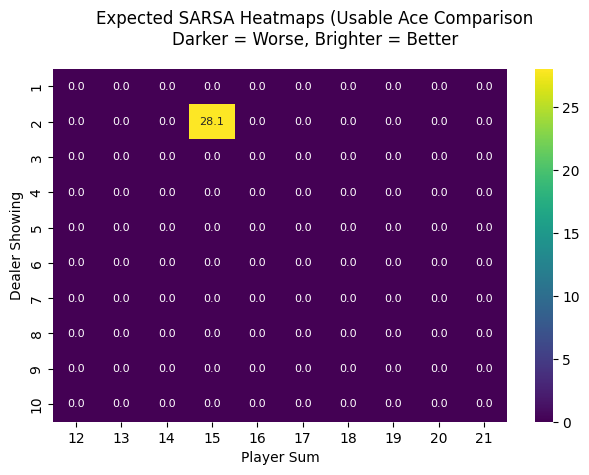

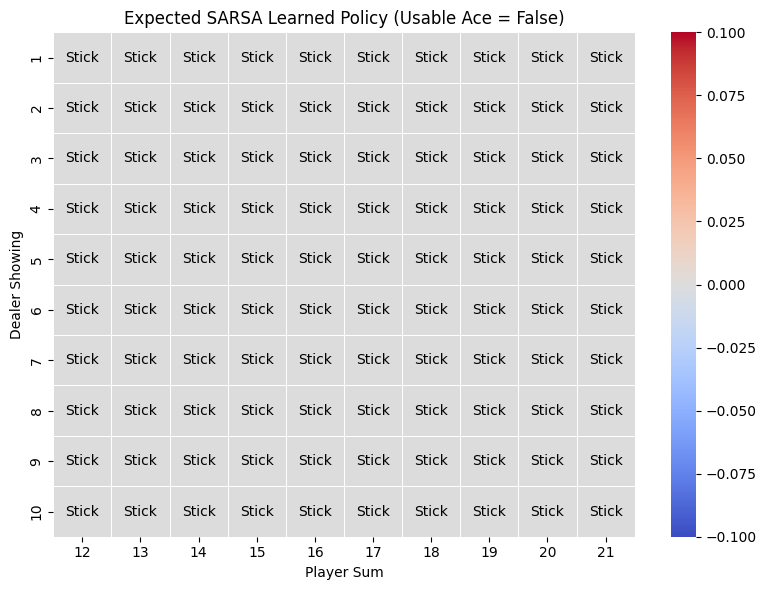

In [58]:
plot_blackjack_q_heatmap(esarsa_agent.Qtable, usable_ace=False, title_prefix="Expected SARSA")
plot_learned_policy(esarsa_agent.Qtable, usable_ace=False, title_prefix="Expected SARSA")

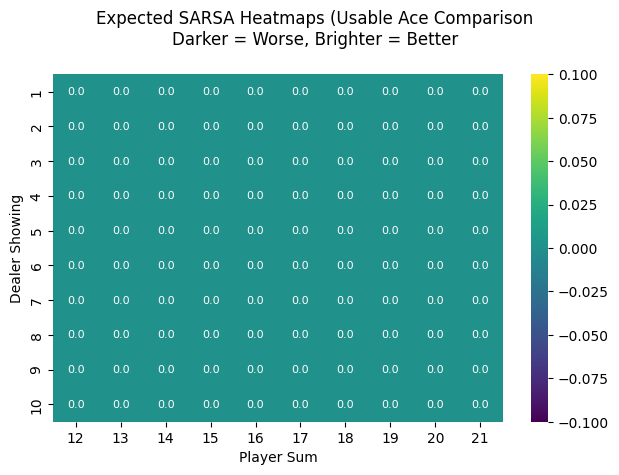

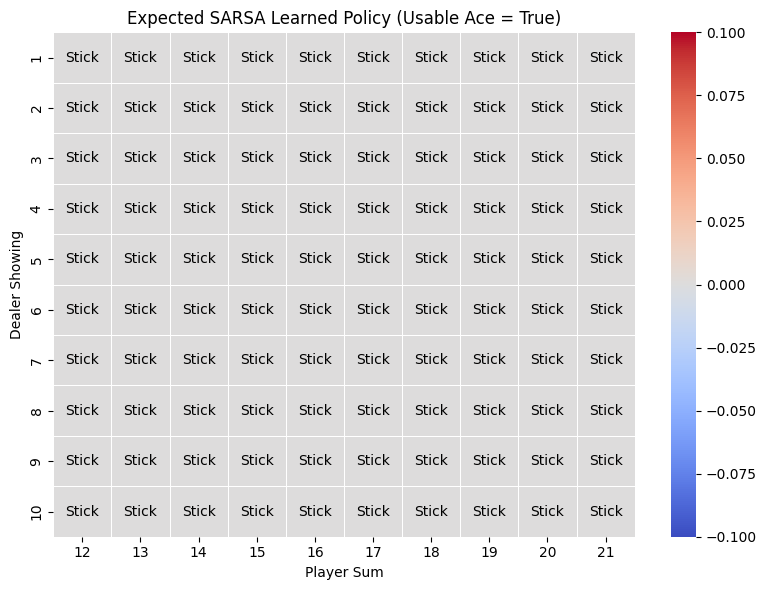

In [59]:
plot_blackjack_q_heatmap(esarsa_agent.Qtable, usable_ace=True, title_prefix="Expected SARSA")
plot_learned_policy(esarsa_agent.Qtable, usable_ace=True, title_prefix="Expected SARSA")